# Upper Confidence Bound algorithme solving multi-armed bandit problem

## Data preprocessing

### Importing the libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the data

In [12]:
dataset = pd.read_csv("Ads_CTR_Optimisation.csv")
dataset.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


In [13]:
oneValue = (dataset == 1).sum()
oneValue

,0
Ad 1,1703
Ad 2,1295
Ad 3,728
Ad 4,1196
Ad 5,2695
Ad 6,126
Ad 7,1112
Ad 8,2091
Ad 9,952
Ad 10,489


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Ad 1    10000 non-null  int64
 1   Ad 2    10000 non-null  int64
 2   Ad 3    10000 non-null  int64
 3   Ad 4    10000 non-null  int64
 4   Ad 5    10000 non-null  int64
 5   Ad 6    10000 non-null  int64
 6   Ad 7    10000 non-null  int64
 7   Ad 8    10000 non-null  int64
 8   Ad 9    10000 non-null  int64
 9   Ad 10   10000 non-null  int64
dtypes: int64(10)
memory usage: 781.4 KB


Text(0, 0.5, 'Ads click rate')

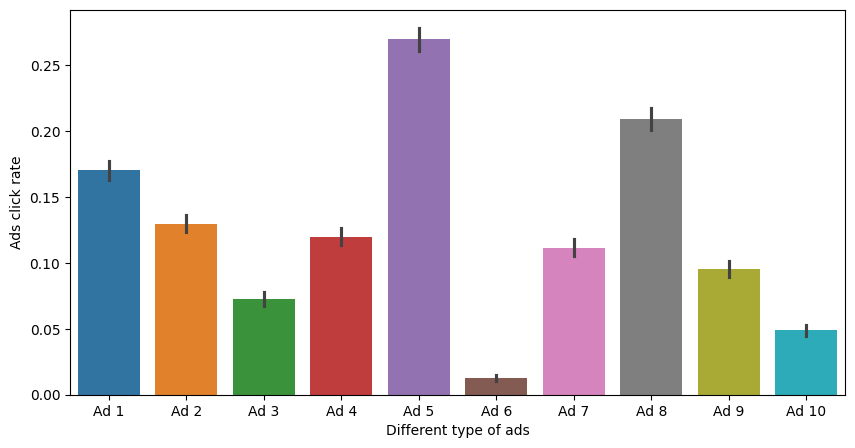

In [15]:
import seaborn as sns

plt.subplots(figsize=(10, 5))
sns.barplot(dataset)
plt.xlabel('Different type of ads')
plt.ylabel('Ads click rate')

## Implementing UCB

In [16]:
import math
N = 1000
d = 10
ads_selected = []
numbers_of_selections = [0] * d
sums_of_rewards = [0] * d
total_reward = 0

for n in range(0, N):
  ad = 0
  max_upper_bound = 0
  for i in range(0, d):
    if(numbers_of_selections[i]>0):
      average_reward = sums_of_rewards[i] / numbers_of_selections[i]
      delta_i = math.sqrt(3/2 * math.log(n+1)/numbers_of_selections[i])
      upper_bound = average_reward + delta_i
    else:
      upper_bound = 1e400
    if(upper_bound > max_upper_bound):
      max_upper_bound = upper_bound
      ad = i
  ads_selected.append(ad)
  numbers_of_selections[ad] += 1
  reward = dataset.values[n, ad]
  sums_of_rewards[ad] = sums_of_rewards[ad] + reward
  total_reward = reward + total_reward


## Visualizing the results

In [17]:
total_reward

np.int64(155)

In [ ]:
plt.subplots(figsize=(10, 5))
plt.hist(ads_selected)
plt.title(f'Histogram of ads selectios with {N} samples')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()